In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

input_images = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")) and "_input" in file.lower():
            input_images.append(os.path.join(root, file))

print("Total Input images:", len(input_images))

Total Input images: 1233


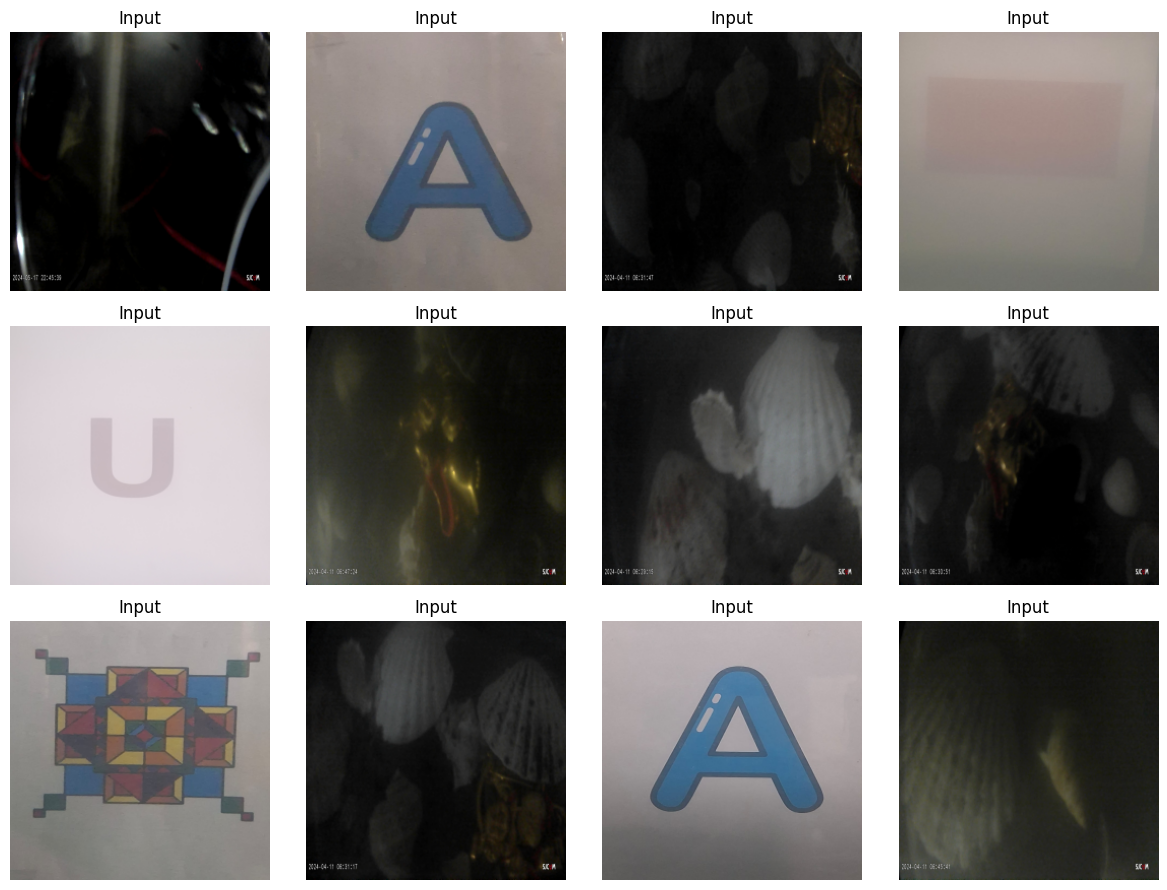

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random_images = random.sample(input_images, min(12, len(input_images)))

plt.figure(figsize=(12, 9))

for i, image_path in enumerate(random_images):
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input")

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

pairs = []

for input_path in input_images:
    folder = os.path.dirname(input_path)
    filename = os.path.basename(input_path)

    sample_id = filename.rsplit("_input", 1)[0]

    target_path = os.path.join(folder, sample_id + "_target.png")
    gen_path = os.path.join(folder, sample_id + "_gen.png")

    if os.path.exists(target_path) and os.path.exists(gen_path):
        pairs.append((input_path, target_path, gen_path))

print("Complete Input-Target-Generated sets:", len(pairs))

Complete Input-Target-Generated sets: 1233


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

pairs = []

for input_path in input_images:
    folder = os.path.dirname(input_path)
    filename = os.path.basename(input_path)

    sample_id = filename.rsplit("_input", 1)[0]

    target_path = os.path.join(folder, sample_id + "_target.png")
    gen_path = os.path.join(folder, sample_id + "_gen.png")

    if os.path.exists(target_path) and os.path.exists(gen_path):
        pairs.append((input_path, target_path, gen_path))

print("Complete Input-Target-Generated sets:", len(pairs))

Complete Input-Target-Generated sets: 1233


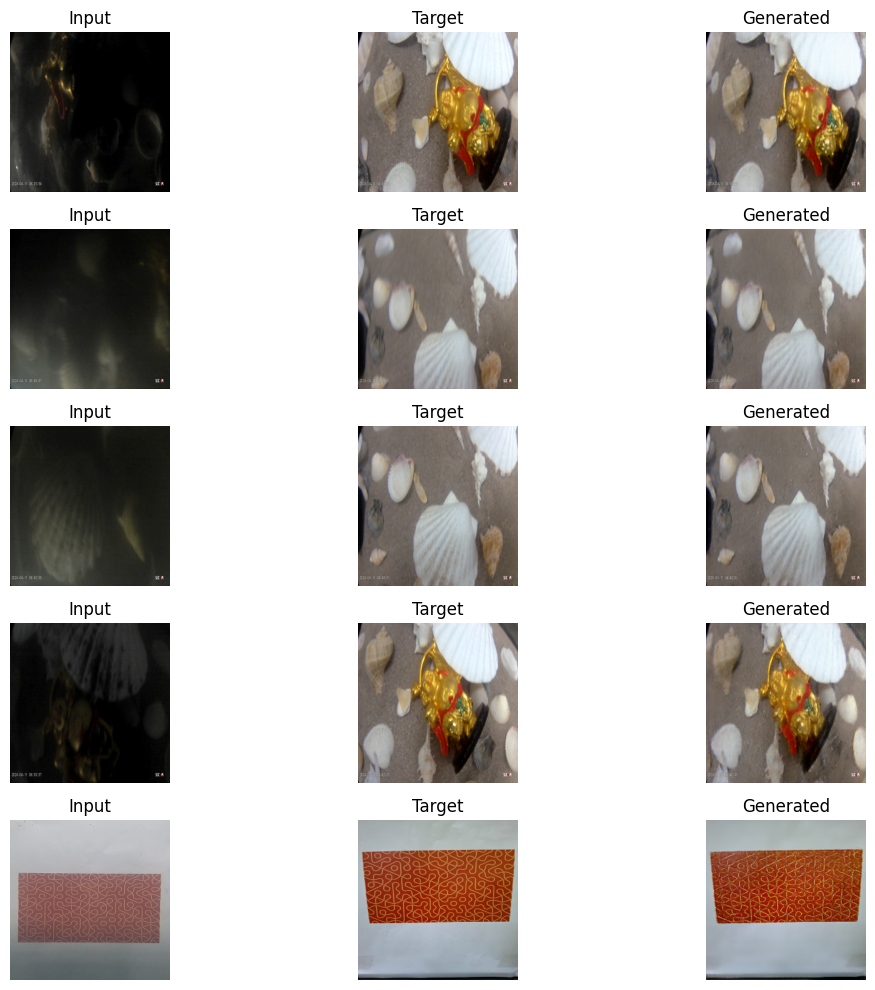

In [ ]:
sample_pairs = random.sample(pairs, min(5, len(pairs)))

plt.figure(figsize=(12, 10))

for i, (input_path, target_path, gen_path) in enumerate(sample_pairs):

    input_img = Image.open(input_path)
    target_img = Image.open(target_path)
    gen_img = Image.open(gen_path)

    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(input_img)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(target_img)
    plt.axis("off")
    plt.title("Target")

    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(gen_img)
    plt.axis("off")
    plt.title("Generated")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image

brightness_values = []

for path in input_images:
    image = Image.open(path).convert("RGB")
    array = np.array(image)

    brightness = np.mean(array)
    brightness_values.append(brightness)

print("Average brightness:", np.mean(brightness_values))
print("Minimum brightness:", np.min(brightness_values))
print("Maximum brightness:", np.max(brightness_values))

Average brightness: 77.38110046716729
Minimum brightness: 0.9742940266927084
Maximum brightness: 246.08775838216147


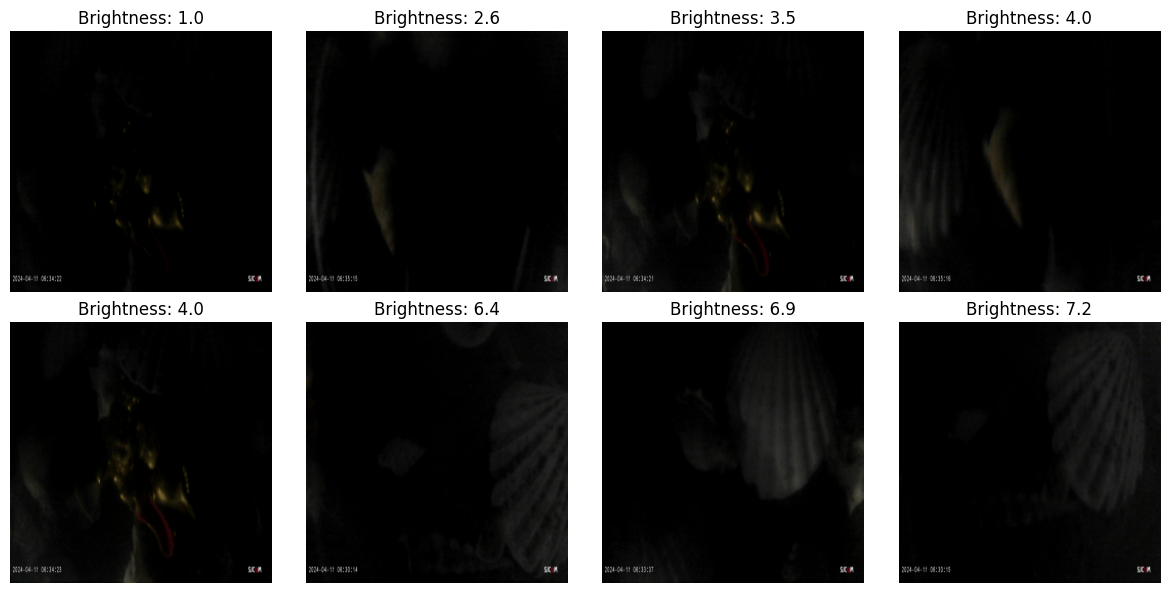

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

dark_indices = np.argsort(brightness_values)[:8]

plt.figure(figsize=(12, 6))

for i, index in enumerate(dark_indices):
    image = Image.open(input_images[index])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Brightness: {brightness_values[index]:.1f}")

plt.tight_layout()
plt.show()

In [ ]:
contrast_values = []

for path in input_images:
    image = Image.open(path).convert("L")
    array = np.array(image)

    contrast = np.std(array)
    contrast_values.append(contrast)

print("Average contrast:", np.mean(contrast_values))
print("Minimum contrast:", np.min(contrast_values))
print("Maximum contrast:", np.max(contrast_values))

Average contrast: 27.64562616794457
Minimum contrast: 2.1909740462394387
Maximum contrast: 73.31811611235676


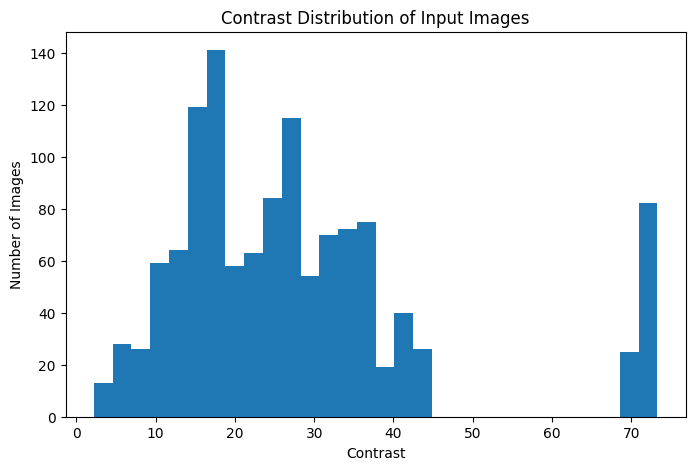

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(contrast_values, bins=30)

plt.xlabel("Contrast")
plt.ylabel("Number of Images")
plt.title("Contrast Distribution of Input Images")

plt.show()

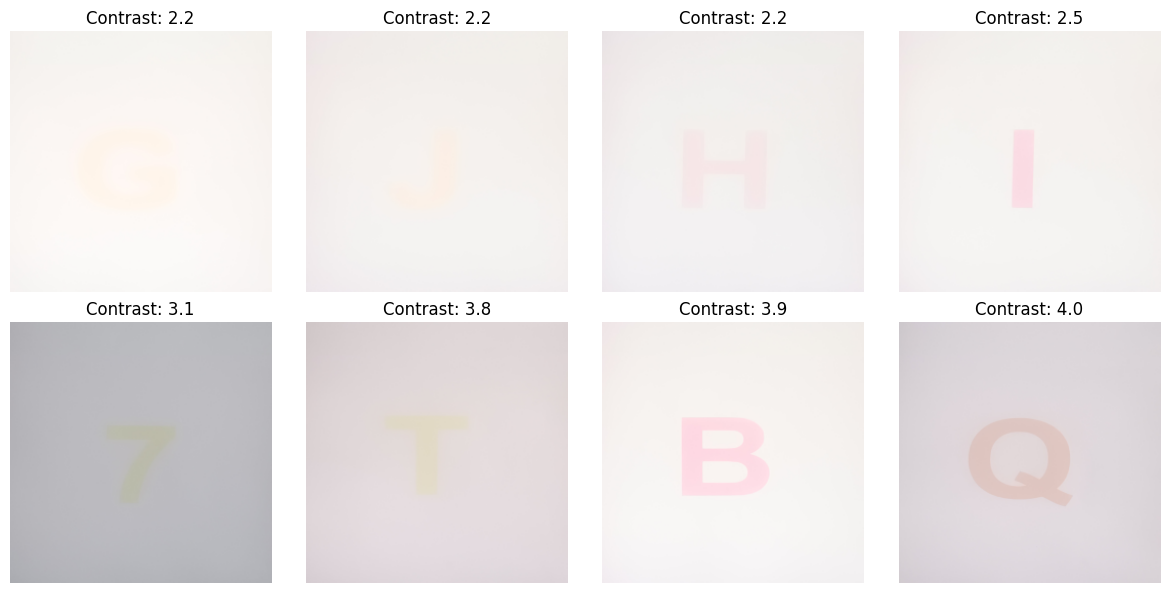

In [ ]:
low_contrast_indices = np.argsort(contrast_values)[:8]

plt.figure(figsize=(12, 6))

for i, index in enumerate(low_contrast_indices):
    image = Image.open(input_images[index])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Contrast: {contrast_values[index]:.1f}")

plt.tight_layout()
plt.show()

Input images by folder:
epoch_0135 : 153
epoch_0110 : 154
epoch_0096 : 157
epoch_100 : 154
epoch_0120 : 153
epoch_0115 : 153
epoch_0100 : 154
epoch_00100 : 155


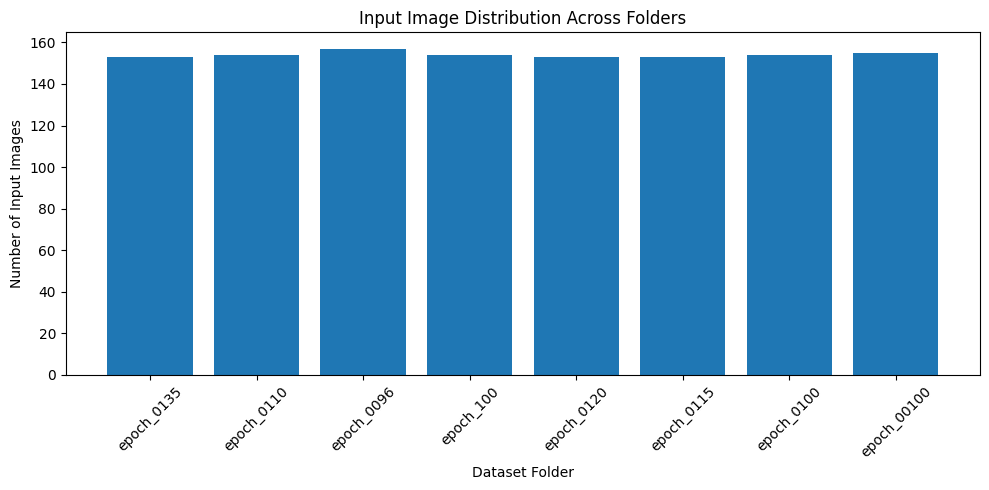

In [ ]:
from collections import Counter
import os
import matplotlib.pyplot as plt

folder_counts = Counter()

for path in input_images:
    relative_path = os.path.relpath(path, BASE_PATH)
    parts = relative_path.split(os.sep)

    if len(parts) > 1:
        folder_counts[parts[0]] += 1

print("Input images by folder:")

for folder, count in folder_counts.items():
    print(folder, ":", count)

plt.figure(figsize=(10, 5))

plt.bar(folder_counts.keys(), folder_counts.values())

plt.xlabel("Dataset Folder")
plt.ylabel("Number of Input Images")
plt.title("Input Image Distribution Across Folders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("========== DAY 10 VISUAL EDA SUMMARY ==========")

print("\nNumber of Input images:", len(input_images))

print("\nBrightness:")
print("Average:", round(np.mean(brightness_values), 2))
print("Minimum:", round(np.min(brightness_values), 2))
print("Maximum:", round(np.max(brightness_values), 2))

print("\nContrast:")
print("Average:", round(np.mean(contrast_values), 2))
print("Minimum:", round(np.min(contrast_values), 2))
print("Maximum:", round(np.max(contrast_values), 2))

print("\nComplete Input-Target-Generated sets:", len(pairs))

print("\n========== HYPOTHESES ==========")

print("1. Dark images may be more difficult to enhance.")
print("2. Low-contrast images may contain less distinguishable details.")
print("3. Haze and color distortion may make underwater enhancement difficult.")
print("4. Different dataset folders may contain different degradation patterns.")

========== DAY 10 VISUAL EDA SUMMARY ==========

Number of Input images: 1233

Brightness:
Average: 77.38
Minimum: 0.97
Maximum: 246.09

Contrast:
Average: 27.65
Minimum: 2.19
Maximum: 73.32

Complete Input-Target-Generated sets: 1233

========== HYPOTHESES ==========
1. Dark images may be more difficult to enhance.
2. Low-contrast images may contain less distinguishable details.
3. Haze and color distortion may make underwater enhancement difficult.
4. Different dataset folders may contain different degradation patterns.
